## ATIVIDADE DO KFOLDS

In [3]:
# ATIVIDADE DO KFOLDS
import numpy as np 
from sklearn import model_selection # corrigindo porque mudou o cross paraa model_selection
from sklearn import datasets
from sklearn import svm

iris = datasets.load_iris() # carregando datasets da iris
# dividindo o dataset em treino e teste
x_train, x_test, y_train, y_test = model_selection.train_test_split(iris.data, iris.target, test_size=0.4, random_state=0)
clf = svm.SVC(kernel='linear', C=1).fit(x_train, y_train) # criando um modelo de previsao  para prever as classes do iris atraves dos treinamentos
clf.score(x_test, y_test) # aveliando o modelo do test comn dados
# trocando o numero de graus do kernel
clf = svm.SVC(kernel='poly', degree=4, C=5).fit(x_train, y_train)
clf.score(x_test, y_test)

0.95

## Atividade do KNN

In [7]:
import pandas as pd
import numpy as np

r_cols = ['user_id', 'movie_id', 'rating'] # Nomes das colunas

ratings = pd.read_csv('codigos/u.data', sep='\t', names=r_cols, usecols=range(3)) # leitura do csv u.data dentro da pasta codigos, aplicando as colunas que queremos ler

ratings.head() # mostrando o topo do dataframe

# agrupando pelo id do filmem e agregando as avalicaoes com a quantidade\ de vezes que o filme foi avaliado e a media das avaliacoes
movieProperties = ratings.groupby('movie_id').agg({'rating': [np.size, np.mean]}) # numero de avaliações e medias de cada filmes
movieProperties.head()

# Criando dataframe com numero de avaliações dos filmes e quantidade de vezes que foi avaliado
movieNumRatings = pd.DataFrame(movieProperties['rating']['size'])
# normalizando o número de avaliacoes onde o valor mínimo será 0 e o máximo será 1
movieNormalizedNumRatings = movieNumRatings.apply(lambda x: (x - np.min(x)) / (np.max(x) - np.min(x))) 
movieNormalizedNumRatings.head()

movieDict = {} # criando um dicionário com as informações dos 

# abrindo o arquivo com as info dos filmes, com encoding latin-1 pq tava dando erro com caracteres especiais no utf-8
with open(r'codigos/u.item', encoding='latin-1') as f:
    temp = ''
    for line in f:  # para cada linha do arquivo
        # campos separados por |
        fields = line.rstrip('\n').split('|')
        #pegando as informações do filme
        movieID = int(fields[0])
        name = fields[1]
        genres = fields[5:25]
         # convertendo os generos para uma lista de int
        genres = list(map(int, genres))
        # adicionando as informações no dicionário
        movieDict[movieID] = (name, genres, movieNormalizedNumRatings.loc[movieID].get('size'), movieProperties.loc[movieID].rating.get('mean'))

from scipy import spatial

def ComputeDistance(a, b):
    
    genresA = a[1] # genero A
    genresB = b[1] # genero B

    #Comparando a distancia do genero utilizando o cosseno para dessemelhança 
    genreDistance = spatial.distance.cosine(genresA, genresB)
    
    popularityA = a[2] # popularidade A
    popularityB = b[2] # popularidade B
    popularityDistance = abs(popularityA - popularityB) # distancia da popularidade

    # avaliação dos filmes a e b
    ratingA = a[3]
    ratingB = b[3]
    # distantica das avaliações entre os filmes
    # divindo por 5(pardronizado de avaliações de até 5 estrelas) para normalizar o valor entre 0 e 1
    ratingDistance = abs(ratingA - ratingB) / 5.

    # colocando pesos diferentes para cada atributo
    genre_weight = 0.6
    popularity_weight = 0.2
    rating_weight = 0.2
    
     # retorna a distancia do genero + a distancia da popularidade + avaliação
    return (genreDistance * genre_weight) + (popularityDistance * popularity_weight) + (ratingDistance * rating_weight)

ComputeDistance(movieDict[2], movieDict[4])

C:\Users\User\AppData\Local\Temp\ipykernel_10876\3055282962.py:11: FutureWarning: The provided callable <function mean at 0x00000256407D4540> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  movieProperties = ratings.groupby('movie_id').agg({'rating': [np.size, np.mean]}) # numero de avaliações e medias de cada filmes


np.float64(0.44052344208169464)

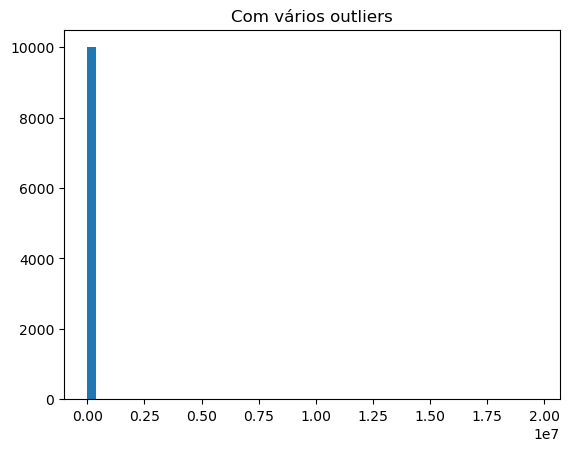

np.float64(60262.26829879988)

In [10]:
%matplotlib inline
import numpy as np

incomes = np.random.normal(27000, 15000, 10000) # gera 10 mil valores random, onde tera uma média de 27 mil e um desvio de 15 mil
incomes = np.append(incomes, [1000000000]) # adicionando o valor de 1 bilhão no vetor

import matplotlib.pyplot as plt
# rendas normais
incomes2 = np.random.normal(27000, 15000, 10000) # gerando 10 mil numeros aleatorios com devio padrao de 15 mil e a media de 27 mil

# gerando 20 outliers muito altos
outliers = np.random.uniform(2000000, 20000000, 30) # aqui estou gerando 30 nuemros aleatorios com valores de 2 milhoes e desvio de 20 milhoes

# adicionando ao conjunto
incomes2 = np.append(incomes2, outliers)

plt.hist(incomes2, 50)
plt.title("Com vários outliers")
plt.show()
incomes2.mean() # media

## Atividade do Outliers

m = 2 -> tamanho final: 10000


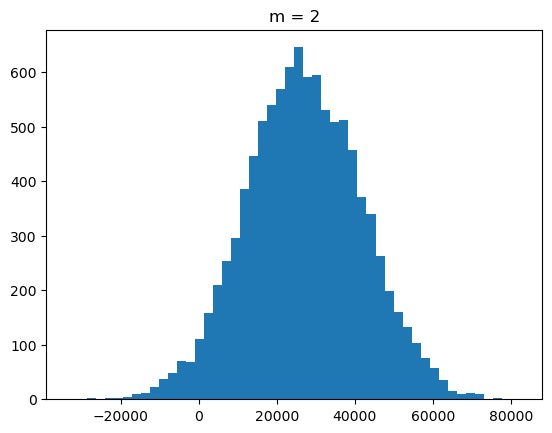

In [11]:
def reject_outliers(data, m): # foi modificado para receber um multiplicador, pois agr tera mais de 1 outlier
    u = np.median(data)
    s = np.std(data)
    return [e for e in data if (u - m*s < e < u + m*s)]
m = 2  # número de desvios padrão permitido
filtered = reject_outliers(incomes, m)
print(f"m = {m} -> tamanho final: {len(filtered)}")
    
plt.hist(filtered, 50)
plt.title(f"m = {m}")
plt.show()

## Atividade PCA

150
4
[np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]


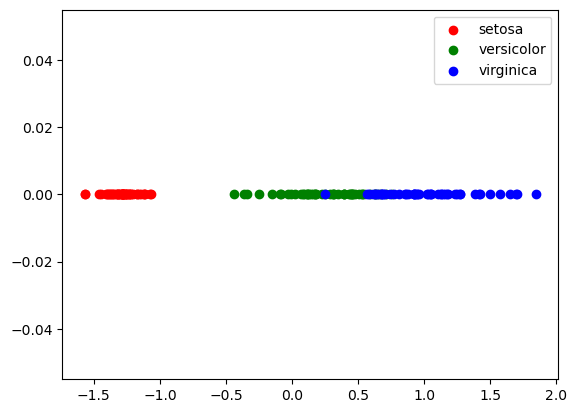

In [17]:
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
import pylab as pl
from itertools import cycle

iris = load_iris() # função que carrega os dados da flor iris

numpSamples, numFeatures = iris.data.shape # extraindo dois dados
print (numpSamples) # quantidade de amostras
print (numFeatures) # quantidade de dimensões
print (list(iris.target_names)) # lista de nomes de classicações da flor iris
Y = iris.data # conjunto de dados
pcaa = PCA(n_components=1, whiten=True).fit(Y) # primeiro definimos a quantidade de dimensões (1) e depois usamos o whiten para normalizar os dados
y_pca = pcaa.transform(Y) # transforma em PCA

colors = cycle ('rgb') # lista de cores
target_ids = range(len(iris.target_names)) # a cor para cada nome da especie(3)
pl.figure()
for i, c, label in zip(target_ids, colors, iris.target_names):
    pl.scatter(
        y_pca[iris.target == i, 0],  # eixo X
        [0] * len(y_pca[iris.target == i]),  # eixo Y fixo (linha reta)
        c=c,
        label=label
    )
pl.legend() # cria a legenda
pl.show() # exibe a iamgem

## Atividade TopPages

In [21]:
import re


# função que formata o log para analise mais facil
format_pat = re.compile(
    r'(?P<host>[\d\.]+)\s'
    r'(?P<identity>\S*)\s'
    r'(?P<user>\S*)\s'
    r'\[(?P<time>.*?)\]\s'
    r'"(?P<request>.*?)"\s'
    r'(?P<status>\d+)\s'
    r'(?P<bytes>\S*)\s'
    r'"(?P<referer>.*?)"\s'
    r'"(?P<user_agent>.*?)"\s*'
)
# caminho do arquivo de log
logPath = "Codigos/access_log.txt" # esta faltando na pasta liberada

URLCounts = {}

with open(logPath, "r") as f:
    for line in (l.rstrip() for l in f):
        match = format_pat.match(line)
        if match:
            access = match.groupdict()
            agent = access['user_agent']
            if (not ('bot' in agent or 'spider' in agent or
                     'Bot' in agent or 'W3 Total Cache' in agent or agent == '-')):
                request = access['request']
                fields = request.split()
                if (len(fields) == 3):
                    (action, URL, protocol) = fields

                    # adicionando a verificação para ver se é um site (termina com "/")
                    if('feed' not in URL): # verifica se não tem feed no URL
                        
                        if (URL.endswith("/")):
                            if (action == 'GET'):
                                if URL in URLCounts:
                                    URLCounts[URL] = URLCounts[URL] + 1
                                else:
                                    URLCounts[URL] = 1

results = sorted(URLCounts, key=lambda i: int(URLCounts[i]), reverse=True)

for result in results[:20]:
    print (result + ": " + str(URLCounts[result]))

/: 77
/orlando-headlines/: 36
/comics-2/: 12
/world/: 12
/weather/: 4
/australia/: 4
/about/: 4
/national-headlines/: 3
/science/: 2
/technology/: 2
/entertainment/: 1
/san-jose-headlines/: 1
/business/: 1


In [22]:
URLCounts = {}

with open(logPath, "r") as f:
    for line in (l.rstrip() for l in f):
        match = format_pat.match(line)
        if match:
            access = match.groupdict()
            agent = access['user_agent']
            if (not ('bot' in agent or 'spider' in agent or
                     'Bot' in agent or 'W3 Total Cache' in agent or agent == '-')):
                request = access['request']
                fields = request.split()
                if (len(fields) == 3):
                    (action, URL, protocol) = fields

                    # adicionando a verificação para ver se é um site (termina com "/")
                    if('feed' in URL): # Diferente de antes vamos verificar as URL que tem o feed

                        if (URL in URLCounts):
                            URLCounts[URL] += 1
                        else:
                            URLCounts[URL] = 1

results = sorted(URLCounts, key=lambda i: int(URLCounts[i]), reverse=True)

for result in results[:20]:
    print (result + ": " + str(URLCounts[result]))
    print("Agent que acessou: " + agent)

/feed/: 2
Agent que acessou: Mozilla/4.0 (compatible: MSIE 7.0; Windows NT 6.0)
/sample-page/feed/: 2
Agent que acessou: Mozilla/4.0 (compatible: MSIE 7.0; Windows NT 6.0)
/?feed=rss2: 1
Agent que acessou: Mozilla/4.0 (compatible: MSIE 7.0; Windows NT 6.0)
/travel/feed/: 1
Agent que acessou: Mozilla/4.0 (compatible: MSIE 7.0; Windows NT 6.0)
